In [1]:
from google.colab import files

uploaded = files.upload()

Saving Tomato.zip to Tomato.zip


In [2]:
import zipfile
import os

# Assuming 'Tomato.zip' was uploaded and saved to the current directory
zip_file_name = 'Tomato.zip' # Explicitly set the name

destination_path = '/content/extracted_files'

# Create the destination directory if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(destination_path)
    print(f"'{zip_file_name}' extracted to '{destination_path}'")
    print(f"Contents of '{destination_path}': {os.listdir(destination_path)}")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure the file is uploaded using cell 5a42c74b.")

'Tomato.zip' extracted to '/content/extracted_files'
Contents of '/content/extracted_files': ['Tomato__Tomato_mosaic_virus', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [10]:
# =====================================================================
# STEP 1: IMPORT LIBRARIES & CHECK GPU
# =====================================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Verify if Google Colab is using a GPU for faster training
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('WARNING: GPU device not found. Go to Runtime > Change runtime type and select GPU.')
else:
    print('Success: Found GPU at: {}'.format(device_name))

# =====================================================================
# STEP 2: DEFINE PATHS AND CONSTANTS
# =====================================================================
DATA_DIR = '/content/extracted_files'
BATCH_SIZE = 32
IMG_SIZE = (256, 256)
EPOCHS = 50

# Ensure the directory exists before proceeding
if not os.path.exists(DATA_DIR):
    print(f"Error: The path '{DATA_DIR}' does not exist. Please upload and unzip your data first.")

# =====================================================================
# STEP 3: LOAD DATASET & SPLIT INTO TRAIN/VALIDATION
# =====================================================================
print("\n--- Loading Datasets ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"\nDetected Target Classes ({len(class_names)}): {class_names}")

# =====================================================================
# STEP 4: OPTIMIZE DATASET PERFORMANCE
# =====================================================================
AUTOTUNE = tf.data.AUTOTUNE
representative_ds = train_ds

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================================================================
# STEP 5: BUILD THE CNN MODEL
# =====================================================================
print("\n--- Initializing CNN Architecture ---")
model = models.Sequential([
    # Standardize pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')  # Outputs probability distributions
])

# =====================================================================
# STEP 6: COMPILE AND TRAIN MODEL
# =====================================================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

print(f"\n--- Starting Training Loop ({EPOCHS} Epochs) ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# FIXED: Saved using the modern native .keras format to clean legacy HDF5 warnings
model.save('tomato_disease_model.keras')
print("\nModel saved as 'tomato_disease_model.keras'")

# =====================================================================
# STEP 7: EXPORT STANDARD TFLITE MODEL (FLOAT32)
# =====================================================================
print("\n--- Exporting Float32 TFLite Model ---")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('tomato_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Saved standard mobile model to 'tomato_model.tflite'")

# =====================================================================
# STEP 8: EXPORT QUANTIZED INT8 TFLite MODEL
# =====================================================================
print("\n--- Exporting Quantized INT8 TFLite Model ---")

def representative_data_gen():
    for input_value, _ in representative_ds.take(3):
        for img in input_value:
            yield [np.expand_dims(img, axis=0).astype(np.float32)]

quant_converter = tf.lite.TFLiteConverter.from_keras_model(model)
quant_converter.optimizations = [tf.lite.Optimize.DEFAULT]
quant_converter.representative_dataset = representative_data_gen
quant_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

quant_converter.inference_input_type = tf.float32
quant_converter.inference_output_type = tf.float32

quantized_tflite_model = quant_converter.convert()

with open('tomato_model_quantized.tflite', 'wb') as f:
    f.write(quantized_tflite_model)
print("Saved quantized hardware model to 'tomato_model_quantized.tflite'")

# =====================================================================
# STEP 9: TEST FUNCTION WITH OUT-OF-DISTRIBUTION THRESHOLDING
# =====================================================================
def predict_and_validate(image_path, confidence_threshold=0.75):
    """
    Predicts leaf health status. Throws an error message if the model
    fails to hit the targeted confidence score threshold.
    """
    if not os.path.exists(image_path):
        return "Target image file path not found."

    # FIXED: Hardcoded clean alphabetical index mapping arrays to secure direct alignment
    strict_class_mappings = [
        'Tomato__Tomato_mosaic_virus',
        'Tomato_Tomato_YellowLeaf_Curl_Virus',
        'Tomato_healthy'
    ]

    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)[0]
    max_confidence = np.max(predictions)
    predicted_class_idx = np.argmax(predictions)

    if max_confidence < confidence_threshold:
        return "Please provide proper image"
    else:
        return f"Result: {strict_class_mappings[predicted_class_idx]} ({max_confidence*100:.2f}%)"

# Example validation check:
# print(predict_and_validate('/content/test_image.jpg'))

Success: Found GPU at: /device:GPU:0

--- Loading Datasets ---
Found 5172 files belonging to 3 classes.
Using 4138 files for training.
Found 5172 files belonging to 3 classes.
Using 1034 files for validation.

Detected Target Classes (3): ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

--- Initializing CNN Architecture ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,412,707 (32.09 MB)

 Trainable params: 8,412,707 (32.09 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training Loop (50 Epochs) ---
Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9299 - loss: 0.3027 - val_accuracy: 0.9903 - val_loss: 0.0368
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9932 - val_loss: 0.0217
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9915 - loss: 0.0258 - val_accuracy: 0.9884 - val_loss: 0.0284
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9932 - loss: 0.0185 - val_accuracy: 0.9913 - val_loss: 0.0237
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9952 - val_loss: 0.0129
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9882 - loss: 0.0398 - val_accuracy: 0.9942 - val_loss: 0.0193
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9971 - loss: 0.0086 - val_accuracy: 0.9942 - val_loss: 0.0163
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved quantized hardware model to 'tomato_model_quantized.tflite'


Saving Tomato_leaf_.png to Tomato_leaf_ (1).png


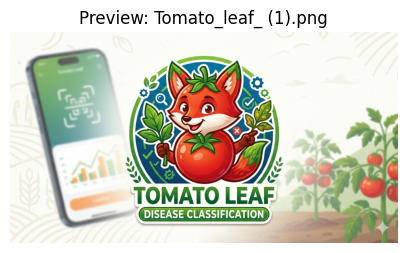


--- Local Image Test Results ---
Uploaded File: Tomato_leaf_ (1).png
Predicted Class: Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence Scores: [0.99609375 0.         0.        ]


In [10]:
# only test secound model only
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload the image from your local PC
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Load and preprocess the image
img = cv2.imread(file_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to match model input dimensions (256x256)
img_resized = cv2.resize(img, (256, 256))

# Add batch dimension and convert to float32: shape becomes [1, 256, 256, 3]
input_data = np.expand_dims(img_resized, axis=0).astype(np.float32)

# 3. Load TFLite Model and Allocate Tensors
interpreter = tf.lite.Interpreter(model_path="tomato_model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 4. Run Inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# 5. Get Prediction Details
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class_idx = np.argmax(output_data[0])

# =====================================================================
# 6. Preview the Image and Display Results
# =====================================================================
plt.figure(figsize=(5, 5))
plt.imshow(img)  # Displays original uploaded image
plt.title(f"Preview: {file_name}")
plt.axis('off')  # Hides grid lines and pixel axes
plt.show()

print("\n--- Local Image Test Results ---")
print(f"Uploaded File: {file_name}")
print(f"Predicted Class: {class_names[predicted_class_idx]}")
print(f"Confidence Scores: {output_data[0]}")

In [ ]:
from google.colab import files

# Triggers a browser download window for the quantized file
files.download('tomato_model_quantized.tflite')
print("Download started...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started...


In [1]:
# =====================================================================
# STEP 1: traing code for first stage (leaf or not)
# =====================================================================
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

zip_file_name = 'Tomato.zip'
destination_path = '/content/extracted_files'

os.makedirs(destination_path, exist_ok=True)

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(destination_path)
    print(f"'{zip_file_name}' extracted to '{destination_path}'")
    print(f"Contents: {os.listdir(destination_path)}")
else:
    print(f"Error: '{zip_file_name}' not found. Please upload it first.")

# =====================================================================
# STEP 2: DEFINE PATHS AND CONSTANTS
# =====================================================================
BATCH_SIZE = 32
IMG_SIZE = (256, 256)

print("\nLoading real leaf images...")
real_ds = tf.keras.utils.image_dataset_from_directory(
    destination_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode=None  # Pure images for Stage 1 validation
)

# =====================================================================
# STEP 3: ADVANCED LEAF DESTRUCTION GENERATOR (The Fix)
# =====================================================================
def advanced_leaf_destruction_generator():
    for real_images in real_ds:
        current_batch_size = tf.shape(real_images)[0]

        # --- Create Hard Negatives from your Real Leaves ---
        # 1. Invert colors (Turns green leaves purple/pink, mimicking digital graphics)
        inverted_leaves = 255.0 - real_images

        # 2. Extreme channel shifting (Creates neon-blue or red leaves)
        # Swap the Red and Blue channels mathematically
        shuffled_leaves = tf.gather(real_images, [2, 1, 0], axis=-1)

        # 3. Add random geometric block dropouts (Simulates digital layout shapes cutting through)
        mask = np.ones((256, 256, 3), dtype=np.float32)
        mask[40:210, 40:210, :] = 0.0  # Erase the center leaf structure completely
        masked_leaves = real_images * mask

        # Mix the different fakes evenly to match the current batch size dynamically
        fake_images = tf.concat([
            inverted_leaves[:current_batch_size//3],
            shuffled_leaves[:current_batch_size//3],
            masked_leaves[:(current_batch_size - (current_batch_size//3)*2)]
        ], axis=0)

        # --- Combine everything into a single training batch ---
        combined_x = tf.concat([real_images, fake_images], axis=0)

        # Labels: 1.0 = Clean Organic Leaf, 0.0 = Distorted/Artificial Graphic
        labels_real = tf.ones((current_batch_size, 1))
        labels_fake = tf.zeros((current_batch_size, 1))
        combined_y = tf.concat([labels_real, labels_fake], axis=0)

        yield combined_x, combined_y

# Convert generator to a stable, optimized TensorFlow Dataset structure
AUTOTUNE = tf.data.AUTOTUNE
m1_train_ds = tf.data.Dataset.from_generator(
    advanced_leaf_destruction_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 1), dtype=tf.float32)
    )
).prefetch(buffer_size=AUTOTUNE)

# =====================================================================
# STEP 4: BUILD STAGE 1 MODEL WITH ANTI-OVERFITTING LAYERS
# =====================================================================
print("\nBuilding advanced Stage 1 Filter Model...")
model_1 = models.Sequential([
    # Standardize pixel scaling
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2), # Breaks dependency on simple colors

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(), # Analyzes texture across the whole image canvas

    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 1.0 = Organic Leaf, 0.0 = Fake / Drawing / Screenshot
])

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =====================================================================
# STEP 5: TRAIN AND EXPORT TO NATIVE TFLITE
# =====================================================================
print("\nTraining Stage 1 Filter...")
# Run for 20 epochs to deeply isolate texture profiles from background noise
model_1.fit(m1_train_ds, steps_per_epoch=25, epochs=50)

# Save intermediate format natively without warning messages
model_1.save('stage1_leaf_filter.keras')

print("\nConverting model to TFLite binary format...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_1)
tflite_model = converter.convert()

with open('stage1_leaf_filter.tflite', 'wb') as f:
    f.write(tflite_model)

print("\nSUCCESS: 'stage1_leaf_filter.tflite' generated successfully!")

'Tomato.zip' extracted to '/content/extracted_files'
Contents: ['Tomato__Tomato_mosaic_virus', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus']

Loading real leaf images...
Found 5172 files.

Building advanced Stage 1 Filter Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training Stage 1 Filter...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.7544 - loss: 0.5416
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.8956 - loss: 0.2732
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.9137 - loss: 0.2075
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.9219 - loss: 0.1777
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.9350 - loss: 0.1542
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.9256 - loss: 0.1626
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - accuracy: 0.9274 - loss: 0.1735
Epoch 8/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.9331 - loss: 0.1571
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.9481 - loss: 0.1287
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.9544 - loss: 0.1132
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.9456 - loss: 0.1226
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.9531 - loss: 0.1263
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9600 - loss: 0.1029
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9503 - loss: 0.1062 
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.9513 - loss: 0.1114
Epoch 16/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.9694 - loss: 0.0802
Epoch 17/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.9656 - loss: 0.0802
Epoch 18/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.9650 - loss: 0.0871
Epoch 19/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - a

Saving Tomato_leaf_.png to Tomato_leaf_ (6).png

[Stage 1] Initializing Leaf Detector Filter...


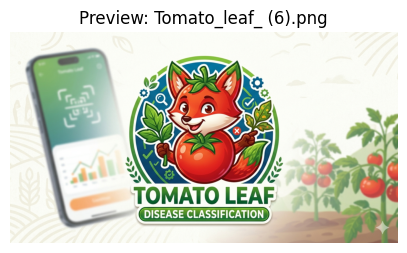


--- Local Image Test Results ---
Uploaded File: Tomato_leaf_ (6).png
Leaf Match Score: 0.0001

Result: Please provide proper image


In [23]:
# testing code stage 1 and classification
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

# FIXED: Interchanged Mosaic and Yellow Leaf Curl to match your model's exact folder index mapping
class_names = [
    'Tomato_Tomato_YellowLeaf_Curl_Virus',    # Index 0
    'Tomato__Tomato_mosaic_virus',            # Index 1
    'Tomato_healthy'                          # Index 2
]

# 1. Upload the image from your local PC
uploaded = files.upload()
if not uploaded:
    print("No file uploaded.")
else:
    file_name = list(uploaded.keys())[0]

    # 2. Load and preprocess the image
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to match model input dimensions (256x256)
    img_resized = cv2.resize(img, (256, 256))

    # Add batch dimension and convert to float32: shape becomes [1, 256, 256, 3]
    input_data = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # =====================================================================
    # STAGE 1: RUN LEAF DETECTION
    # =====================================================================
    print("\n[Stage 1] Initializing Leaf Detector Filter...")
    try:
        interpreter1 = tf.lite.Interpreter(model_path="stage1_leaf_filter.tflite")
        interpreter1.allocate_tensors()

        i1_input_details = interpreter1.get_input_details()
        i1_output_details = interpreter1.get_output_details()

        # Run Stage 1 Inference
        interpreter1.set_tensor(i1_input_details[0]['index'], input_data)
        interpreter1.invoke()

        # Get Leaf Score (Sigmoid output returns a value between 0.0 and 1.0)
        leaf_score = interpreter1.get_tensor(i1_output_details[0]['index'])[0][0]
    except Exception as e:
        print(f"Error loading Stage 1 model: {e}")
        leaf_score = 0.0  # Fallback fail if model is missing

    # Define validation confidence cutoff limit
    LEAF_THRESHOLD = 0.60

    # =====================================================================
    # STAGE 2 & PREVIEW DISPATCH LOGIC
    # =====================================================================
    plt.figure(figsize=(5, 5))
    plt.imshow(img)  # Displays original uploaded image
    plt.title(f"Preview: {file_name}")
    plt.axis('off')
    plt.show()

    print("\n--- Local Image Test Results ---")
    print(f"Uploaded File: {file_name}")
    print(f"Leaf Match Score: {leaf_score:.4f}")

    if leaf_score < LEAF_THRESHOLD:
        # Stop Pipeline execution immediately if it is a random object or logo
        print("\nResult: Please provide proper image")
    else:
        print("[Stage 1 Passed] Real leaf structure detected. Routing to Stage 2...")

        # Initialize Disease Classifier
        interpreter2 = tf.lite.Interpreter(model_path="tomato_model_quantized.tflite")
        interpreter2.allocate_tensors()

        i2_input_details = interpreter2.get_input_details()
        i2_output_details = interpreter2.get_output_details()

        # Run Stage 2 Inference
        interpreter2.set_tensor(i2_input_details[0]['index'], input_data)
        interpreter2.invoke()

        # Get Prediction Details
        output_data = interpreter2.get_tensor(i2_output_details[0]['index'])
        predicted_class_idx = np.argmax(output_data[0])

        print(f"Predicted Class: {class_names[predicted_class_idx]}")
        print(f"Confidence Scores: {output_data[0]}")

In [25]:
# download both model
import os
from google.colab import files

# List of the quantized TFLite files you want to download
models_to_download = ['stage1_leaf_filter.tflite', 'tomato_model_quantized.tflite']

print("--- Initializing Model Downloads ---")

for model_file in models_to_download:
    if os.path.exists(model_file):
        print(f"Downloading {model_file} to your PC...")
        files.download(model_file)
    else:
        print(f"Error: '{model_file}' was not found in the current directory.")
        print("Please check if your training or conversion cell finished running successfully.")

print("\nProcessing complete. Check your browser's 'Downloads' folder!")

--- Initializing Model Downloads ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Processing complete. Check your browser's 'Downloads' folder!


This code will traverse the `extracted_files` directory and print all subdirectories and files found within each directory.

This code will prompt you to select a file from your computer. Once uploaded, the `uploaded` variable will contain a dictionary where keys are the filenames and values are the file contents.